In [12]:
import os
from pathlib import Path
cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [13]:
import os, math, json
from pathlib import Path
import numpy as np
import torch
import pandas as pd

import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.spatial.distance import jensenshannon

In [ ]:
RESULTS_PATH = "data/experiments/group_patching/vitbase_neutrality/group_patching_results.pt"

res = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)
print(res.keys())
print("has original:", "original" in res, "| has patched:", "patched" in res)

# # quick peek
print("streams in layer_0:", list(res["patched"]["layer_1"].keys()))
first_stream = list(res["patched"]["layer_1"].keys())[0]
first_combo = list(res["patched"]["layer_1"][first_stream].keys())[0]
print("example combo:", first_combo)
print("keys inside combo:", res["patched"]["layer_1"][first_stream][first_combo].keys())


dict_keys(['original', 'corrupted', 'patched', 'emotion_map', 'groups_json_path', 'file_key', 'groups', 'combo_names'])
has original: True | has patched: True
streams in layer_0: ['block_output', 'attention_output', 'mlp_activation']
example combo: skin
keys inside combo: dict_keys(['patched_groups', 'patched_patch_indices', 'final_probs', 'probe_next_layer_probs'])


In [15]:
res["patched"]["layer_1"][first_stream][first_combo]['probe_next_layer_probs']

array([[5.38120889e-02, 1.08368734e-08, 9.36420589e-01, 9.76065920e-03,
        1.45459825e-06, 5.19750281e-06]])

In [16]:
EPS = 1e-12

def to_np_probs(x):
    """Convert stored probs to numpy [C]. Accepts np [1,C], torch [1,C], list, etc."""
    if x is None:
        return None
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    x = np.asarray(x)
    if x.ndim == 2 and x.shape[0] == 1:
        x = x[0]
    assert x.ndim == 1, f"expected [C], got {x.shape}"
    # numeric safety
    x = np.clip(x, EPS, 1.0)
    x = x / x.sum()
    return x

def kl_div(p, q):
    """KL(p || q)"""
    p = np.clip(p, EPS, 1.0); p = p / p.sum()
    q = np.clip(q, EPS, 1.0); q = q / q.sum()
    return float(np.sum(p * (np.log(p) - np.log(q))))

def js_div(p, q):
    """Jensen-Shannon divergence (base e)."""
    p = np.clip(p, EPS, 1.0); p = p / p.sum()
    q = np.clip(q, EPS, 1.0); q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * kl_div(p, m) + 0.5 * kl_div(q, m)

def l1_dist(p, q):
    return float(np.sum(np.abs(p - q)))

def entropy(p):
    p = np.clip(p, EPS, 1.0); p = p / p.sum()
    return float(-np.sum(p * np.log(p)))

def top1(p):
    return int(np.argmax(p))

def delta_p_correct(p_base, p_new, correct_idx):
    return float(p_new[correct_idx] - p_base[correct_idx])

def delta_p_pred(p_base, p_new):
    pred = top1(p_base)
    return float(p_new[pred] - p_base[pred])

def flip(base_probs, new_probs):
    return top1(base_probs) != top1(new_probs)


In [17]:
orig_final = to_np_probs(res["original"]["final_probs"])
corr_final = to_np_probs(res["corrupted"]["final_probs"])

correct_idx = None
md = res["original"].get("metadata", {})
if isinstance(md, dict):
    val = md['emotion']
    if isinstance(val, str) and "emotion_map" in res:
        rev = {v[0]:k for k,v in res["emotion_map"].items()}
        if val in rev:
            correct_idx = int(rev[val])

if correct_idx is None:
    correct_idx = int(np.argmax(orig_final))
    print("WARNING: correct_idx not found in metadata. Using baseline top-1 as 'correct' =", correct_idx)
else:
    print("correct_idx from metadata =", correct_idx)

print("orig top1:", np.argmax(orig_final), "corr top1:", np.argmax(corr_final), "correct_idx:", correct_idx)


correct_idx from metadata = 1
orig top1: 1 corr top1: 2 correct_idx: 1


In [18]:
res["emotion_map"]

{0: 'neutrality',
 1: 'happiness',
 2: 'sadness',
 3: 'anger',
 4: 'disgust',
 5: 'fear'}

In [19]:
rows = []

base = orig_final

for layer_key, layer_dict in tqdm(res["patched"].items()):
    layer_idx = int(layer_key.split("_")[1])
    for stream, combos in layer_dict.items():
        for combo_name, payload in combos.items():
            p_final = to_np_probs(payload.get("final_probs"))
            p_probe = to_np_probs(payload.get("probe_next_layer_probs"))

            row = {
                "layer": layer_idx,
                "stream": stream,
                "combo": combo_name,
                "n_patches": len(payload.get("patched_patch_indices", [])),
                "final_top1": top1(p_final),
                "final_flip": flip(base, p_final),
                "delta_p_correct": delta_p_correct(base, p_final, correct_idx),
                "delta_p_pred": delta_p_pred(base, p_final),
                "KL_base_to_patched": kl_div(base, p_final),
                "KL_patched_to_base": kl_div(p_final, base),
                "JS": js_div(base, p_final),
                "L1": l1_dist(base, p_final),
                "H_base": entropy(base),
                "H_patched": entropy(p_final),
                "delta_entropy": entropy(p_final) - entropy(base),
            }

            if p_probe is not None:
                row.update({
                    "probe_top1": top1(p_probe),
                    "probe_flip_vs_base": flip(base, p_probe),
                    "probe_delta_p_correct": delta_p_correct(base, p_probe, correct_idx),
                    "probe_JS": js_div(base, p_probe),
                    "probe_L1": l1_dist(base, p_probe),
                })
            else:
                row.update({
                    "probe_top1": None,
                    "probe_flip_vs_base": None,
                    "probe_delta_p_correct": None,
                    "probe_JS": None,
                    "probe_L1": None,
                })

            rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head()



100%|██████████| 12/12 [00:00<00:00, 120.47it/s]

(540, 20)


,layer,stream,combo,n_patches,final_top1,final_flip,delta_p_correct,delta_p_pred,KL_base_to_patched,KL_patched_to_base,JS,L1,H_base,H_patched,delta_entropy,probe_top1,probe_flip_vs_base,probe_delta_p_correct,probe_JS,probe_L1
0,0,block_output,skin,59,2,True,-1.000000e+00,-1.000000e+00,2.763102e+01,2.763099e+01,6.931472e-01,2.000000e+00,9.642096e-08,3.345412e-05,3.335770e-05,0.0,True,-0.936438,0.572796,1.872875
1,0,block_output,brows,3,1,False,1.185203e-09,1.185203e-09,1.844353e-10,1.651619e-10,4.342919e-11,2.370407e-09,9.642096e-08,7.345631e-08,-2.296465e-08,0.0,True,-0.962515,0.612510,1.925029
2,0,block_output,lips,11,0,True,-9.999999e-01,-9.999999e-01,1.598550e+01,2.747375e+01,6.931462e-01,2.000000e+00,9.642096e-08,1.566418e-01,1.566417e-01,0.0,True,-0.964179,0.615292,1.928358
3,0,block_output,neck,28,1,False,-5.018906e-07,-5.018906e-07,4.796429e-07,1.863843e-06,1.637286e-07,1.003781e-06,9.642096e-08,7.865347e-06,7.768926e-06,0.0,True,-0.941400,0.579881,1.882801
4,0,block_output,skin+brows,59,2,True,-1.000000e+00,-1.000000e+00,2.763102e+01,2.763099e+01,6.931472e-01,2.000000e+00,9.642096e-08,3.345412e-05,3.335770e-05,0.0,True,-0.936438,0.572796,1.872875


In [20]:
def show_top(df, metric, n=15, ascending=True):
    display(df.sort_values(metric, ascending=ascending).head(n)[
        ["layer","stream","combo","n_patches", metric, "final_top1", "final_flip"]
    ])

print("Top combos by MOST NEGATIVE delta_p_correct (bigger harm => more negative):")
show_top(df, "delta_p_correct", n=15, ascending=True)

print("\nTop combos by largest JS divergence:")
show_top(df, "JS", n=15, ascending=False)

print("\nFlip rate by combo (aggregated over layer+stream):")
flip_tbl = (
    df.groupby("combo")["final_flip"].mean()
      .sort_values(ascending=False)
      .reset_index()
      .rename(columns={"final_flip":"flip_rate"})
)
display(flip_tbl.head(40))


Top combos by MOST NEGATIVE delta_p_correct (bigger harm => more negative):


,layer,stream,combo,n_patches,delta_p_correct,final_top1,final_flip
0,0,block_output,skin,59,-1.0,2,True
36,0,mlp_activation,skin+neck,78,-1.0,2,True
39,0,mlp_activation,lips+neck,38,-1.0,2,True
44,0,mlp_activation,skin+brows+lips+neck,78,-1.0,2,True
43,0,mlp_activation,brows+lips+neck,41,-1.0,2,True
42,0,mlp_activation,skin+lips+neck,78,-1.0,2,True
41,0,mlp_activation,skin+brows+neck,78,-1.0,2,True
40,0,mlp_activation,skin+brows+lips,59,-1.0,2,True
45,1,block_output,skin,59,-1.0,2,True
55,1,block_output,skin+brows+lips,59,-1.0,2,True



Top combos by largest JS divergence:


,layer,stream,combo,n_patches,JS,final_top1,final_flip
10,0,block_output,skin+brows+lips,59,0.693147,2,True
5,0,block_output,skin+lips,59,0.693147,2,True
4,0,block_output,skin+brows,59,0.693147,2,True
0,0,block_output,skin,59,0.693147,2,True
45,1,block_output,skin,59,0.693147,2,True
50,1,block_output,skin+lips,59,0.693147,2,True
49,1,block_output,skin+brows,59,0.693147,2,True
55,1,block_output,skin+brows+lips,59,0.693147,2,True
100,2,block_output,skin+brows+lips,59,0.693147,2,True
95,2,block_output,skin+lips,59,0.693147,2,True



Flip rate by combo (aggregated over layer+stream):


,combo,flip_rate
0,skin+lips+neck,0.361111
1,skin+lips,0.361111
2,skin+brows+neck,0.361111
3,skin+brows+lips+neck,0.361111
4,skin+brows+lips,0.361111
5,skin+brows,0.361111
6,skin,0.361111
7,skin+neck,0.361111
8,brows+lips+neck,0.305556
9,lips+neck,0.277778


In [21]:
def heatmap_layer_combo(df_sub, metric, title=None):
    pivot = df_sub.pivot_table(index="combo", columns="layer", values=metric, aggfunc="mean")

    plt.figure(figsize=(12, max(4, 0.35 * len(pivot.index))))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label=metric)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
    plt.xlabel("Layer")
    plt.ylabel("Combo")
    plt.title(title or f"Heatmap: {metric}")
    plt.tight_layout()
    plt.show()
    return pivot


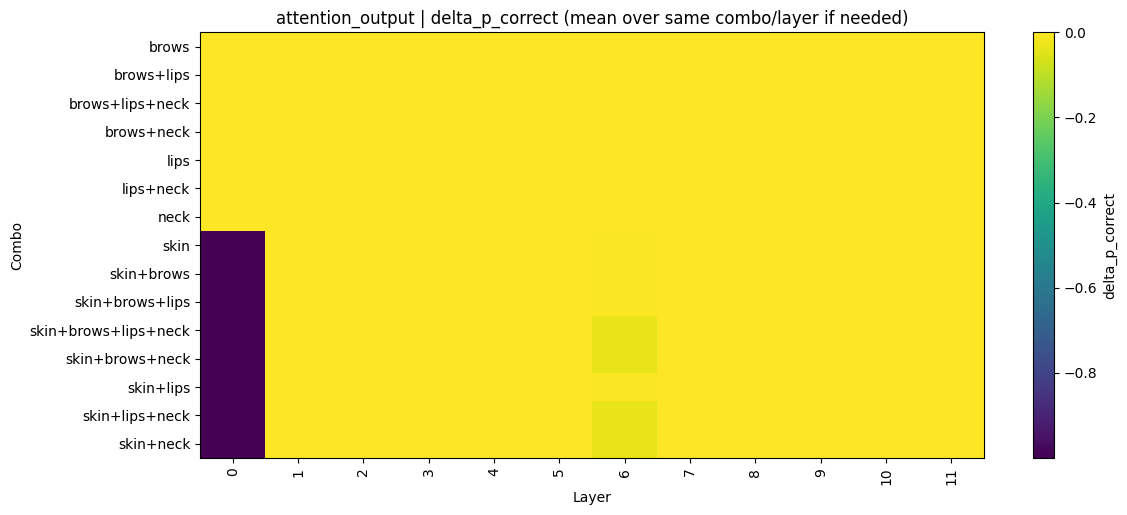

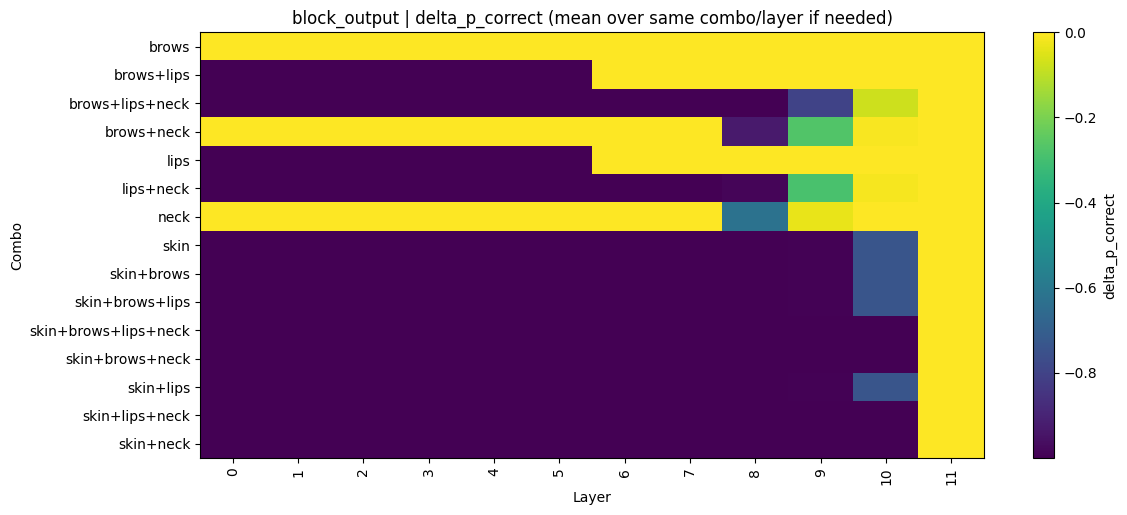

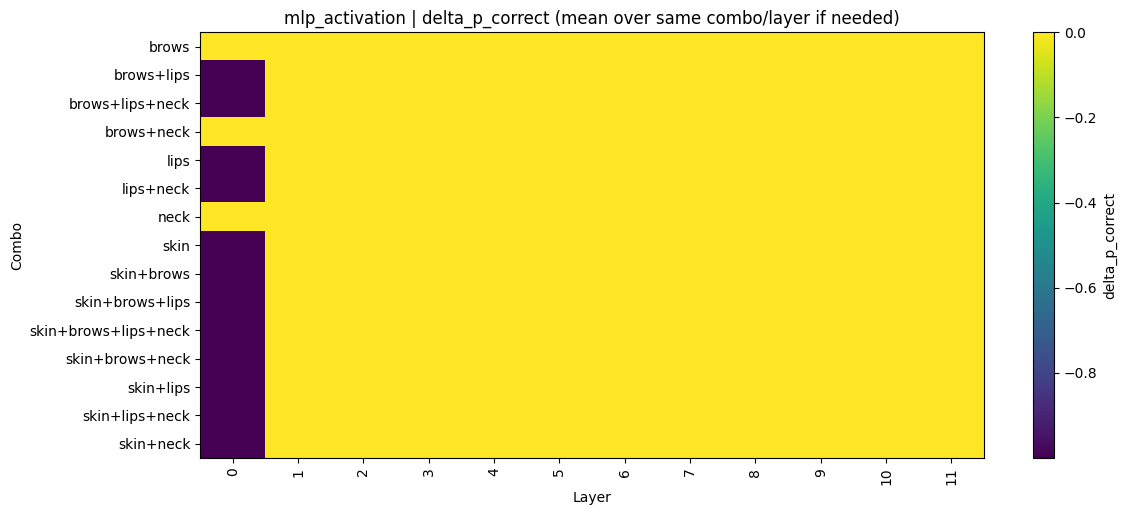

In [22]:
METRICS = ["delta_p_correct"]

for stream in sorted(df["stream"].unique()):
    df_s = df[df["stream"] == stream].copy()

    for m in METRICS:
        heatmap_layer_combo(
            df_s, m,
            title=f"{stream} | {m} (mean over same combo/layer if needed)"
        )


In [23]:
def best_layer_per_combo(df_sub, metric, mode="min"):
    out = []
    for combo, g in df_sub.groupby("combo"):
        if mode == "min":
            idx = g[metric].idxmin()
        else:
            idx = g[metric].idxmax()
        row = g.loc[idx, ["combo","layer","stream",metric,"n_patches","final_top1","final_flip"]].to_dict()
        out.append(row)
    return pd.DataFrame(out).sort_values(metric, ascending=(mode=="min"))

# For delta_p_correct => min is strongest negative
best_delta = best_layer_per_combo(df, "delta_p_correct", mode="min")
display(best_delta.head(20))



,combo,layer,stream,delta_p_correct,n_patches,final_top1,final_flip
2,brows+lips+neck,0,block_output,-1.000000e+00,41,2,True
5,lips+neck,0,block_output,-1.000000e+00,38,2,True
7,skin,0,block_output,-1.000000e+00,59,2,True
12,skin+lips,0,block_output,-1.000000e+00,59,2,True
11,skin+brows+neck,0,block_output,-1.000000e+00,78,2,True
10,skin+brows+lips+neck,0,block_output,-1.000000e+00,78,2,True
9,skin+brows+lips,0,block_output,-1.000000e+00,59,2,True
8,skin+brows,0,block_output,-1.000000e+00,59,2,True
14,skin+neck,0,block_output,-1.000000e+00,78,2,True
13,skin+lips+neck,0,block_output,-1.000000e+00,78,2,True


Top combos: ['brows+lips+neck', 'lips+neck', 'skin', 'skin+lips', 'skin+brows+neck', 'skin+brows+lips+neck', 'skin+brows+lips', 'skin+brows', 'skin+neck', 'skin+lips+neck', 'lips', 'brows+lips', 'brows+neck', 'neck', 'brows']


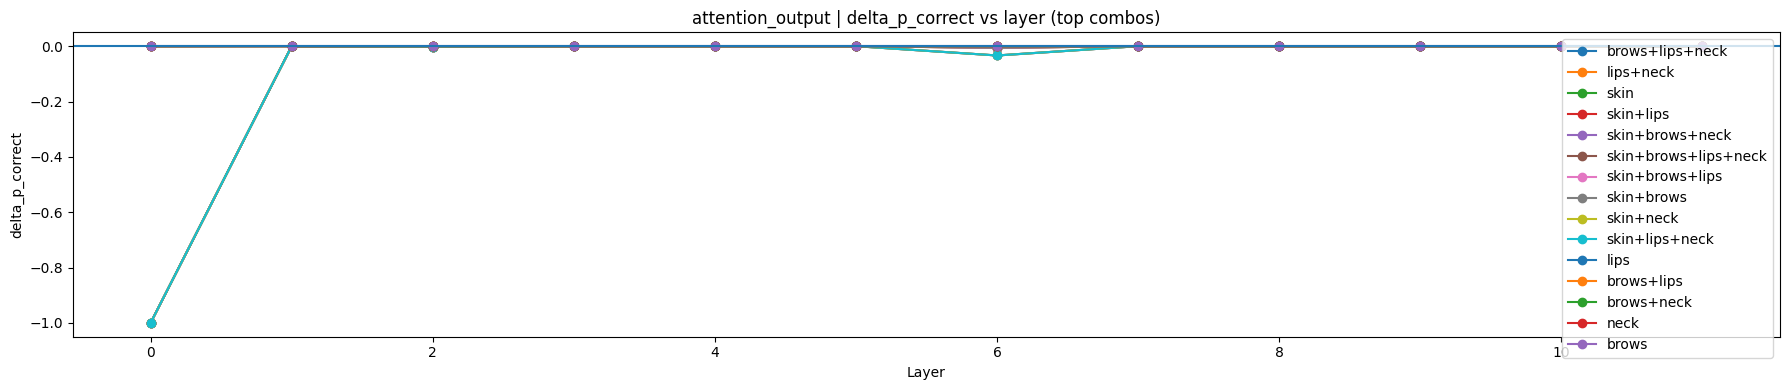

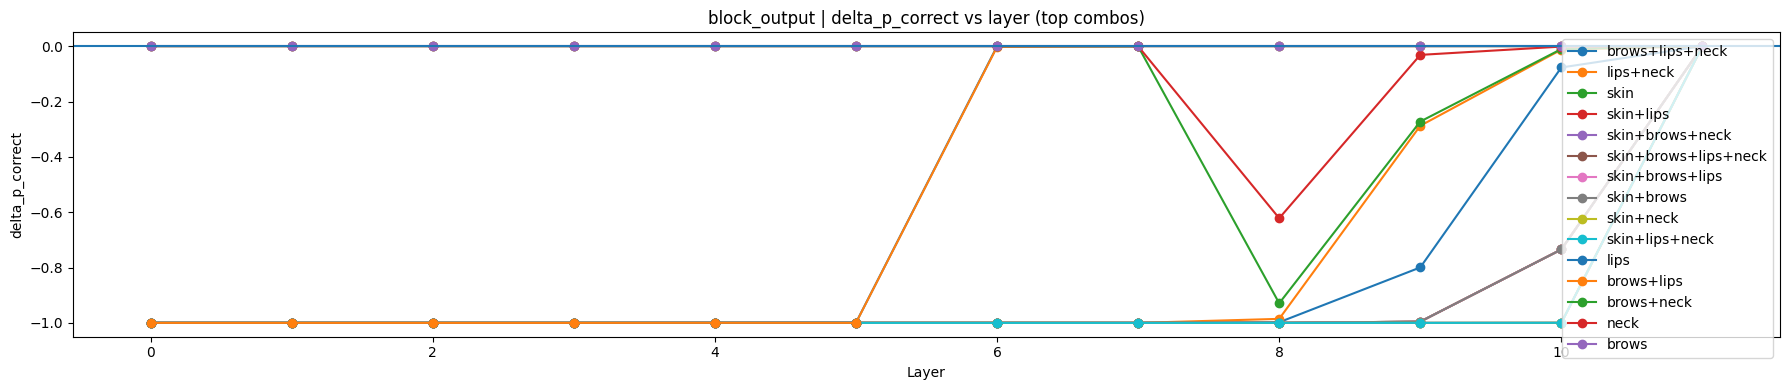

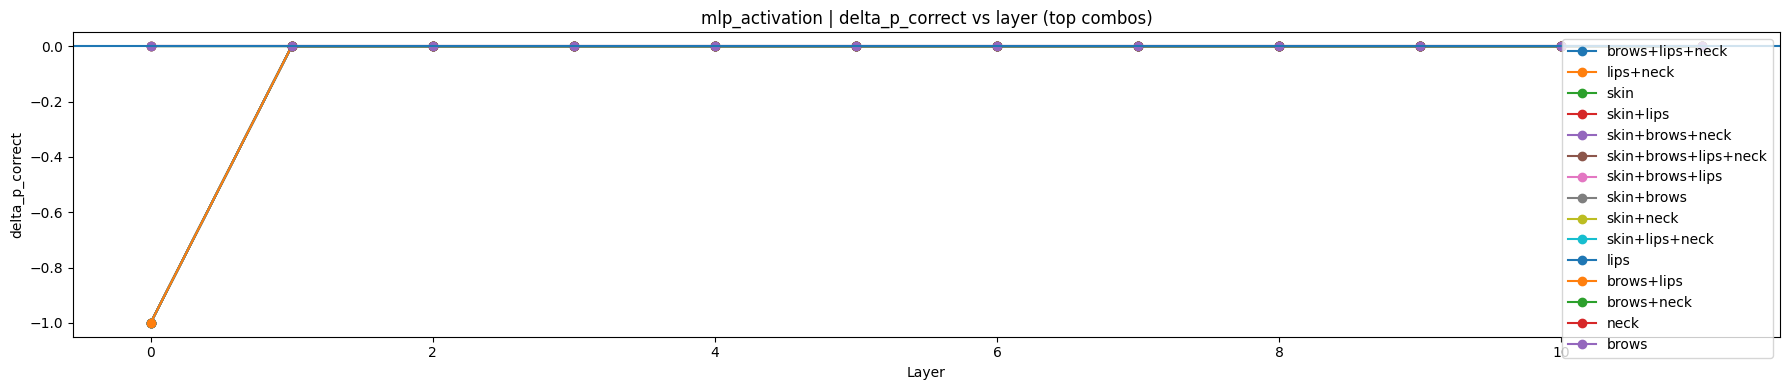

In [24]:
TOPK = 15

top_combos = (
    df.groupby("combo")["delta_p_correct"].min()
      .sort_values()
      .head(TOPK)
      .index
      .tolist()
)
print("Top combos:", top_combos)

metric = "delta_p_correct"  # try "JS", "L1"
for stream in sorted(df["stream"].unique()):
    plt.figure(figsize=(18,4))
    for combo in top_combos:
        g = df[(df["combo"]==combo) & (df["stream"]==stream)].sort_values("layer")
        plt.plot(g["layer"], g[metric], marker="o", label=combo)
    plt.axhline(0.0)
    plt.title(f"{stream} | {metric} vs layer (top combos)")
    plt.xlabel("Layer")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [25]:
agg = (
    df.groupby(["stream","combo"])
      .agg(
          worst_delta=("delta_p_correct","min"),   # most negative
          max_JS=("JS","max"),
          max_L1=("L1","max"),
          flip_rate=("final_flip","mean"),
          n_patches=("n_patches","max"),
      )
      .reset_index()
)

display(agg.sort_values("worst_delta").head(20))
display(agg.sort_values("max_JS", ascending=False).head(20))


,stream,combo,worst_delta,max_JS,max_L1,flip_rate,n_patches
24,block_output,skin+brows+lips,-1.0,0.693147,2.0,0.916667,59
25,block_output,skin+brows+lips+neck,-1.0,0.693147,2.0,0.916667,78
26,block_output,skin+brows+neck,-1.0,0.693147,2.0,0.916667,78
27,block_output,skin+lips,-1.0,0.693147,2.0,0.916667,59
20,block_output,lips+neck,-1.0,0.693147,2.0,0.750000,38
22,block_output,skin,-1.0,0.693147,2.0,0.916667,59
29,block_output,skin+neck,-1.0,0.693147,2.0,0.916667,78
28,block_output,skin+lips+neck,-1.0,0.693147,2.0,0.916667,78
23,block_output,skin+brows,-1.0,0.693147,2.0,0.916667,59
17,block_output,brows+lips+neck,-1.0,0.693147,2.0,0.833333,41


,stream,combo,worst_delta,max_JS,max_L1,flip_rate,n_patches
27,block_output,skin+lips,-1.0,0.693147,2.0,0.916667,59
22,block_output,skin,-1.0,0.693147,2.0,0.916667,59
23,block_output,skin+brows,-1.0,0.693147,2.0,0.916667,59
24,block_output,skin+brows+lips,-1.0,0.693147,2.0,0.916667,59
25,block_output,skin+brows+lips+neck,-1.0,0.693147,2.0,0.916667,78
29,block_output,skin+neck,-1.0,0.693147,2.0,0.916667,78
26,block_output,skin+brows+neck,-1.0,0.693147,2.0,0.916667,78
28,block_output,skin+lips+neck,-1.0,0.693147,2.0,0.916667,78
40,mlp_activation,skin+brows+lips+neck,-1.0,0.693147,2.0,0.083333,78
41,mlp_activation,skin+brows+neck,-1.0,0.693147,2.0,0.083333,78


In [26]:
C = len(base)
base_top = int(np.argmax(base))

combo_shift_rows = []
for (stream, combo), g in df.groupby(["stream","combo"]):
    top_counts = g["final_top1"].value_counts()
    most_common_top = int(top_counts.index[0])
    frac = float(top_counts.iloc[0] / top_counts.sum())

    worst_row = g.loc[g["delta_p_correct"].idxmin()]
    combo_shift_rows.append({
        "stream": stream,
        "combo": combo,
        "n_patches": int(worst_row["n_patches"]),
        "baseline_top": base_top,
        "most_common_patched_top": most_common_top,
        "most_common_frac": frac,
        "worst_delta_p_correct": float(worst_row["delta_p_correct"]),
        "flip_rate": float(g["final_flip"].mean()),
    })

combo_shift = pd.DataFrame(combo_shift_rows)
display(combo_shift.sort_values(["worst_delta_p_correct"]).head(30))


,stream,combo,n_patches,baseline_top,most_common_patched_top,most_common_frac,worst_delta_p_correct,flip_rate
24,block_output,skin+brows+lips,59,1,2,0.750000,-1.000000,0.916667
25,block_output,skin+brows+lips+neck,78,1,2,0.833333,-1.000000,0.916667
26,block_output,skin+brows+neck,78,1,2,0.833333,-1.000000,0.916667
27,block_output,skin+lips,59,1,2,0.750000,-1.000000,0.916667
20,block_output,lips+neck,38,1,2,0.750000,-1.000000,0.750000
22,block_output,skin,59,1,2,0.750000,-1.000000,0.916667
29,block_output,skin+neck,78,1,2,0.833333,-1.000000,0.916667
28,block_output,skin+lips+neck,78,1,2,0.833333,-1.000000,0.916667
23,block_output,skin+brows,59,1,2,0.750000,-1.000000,0.916667
17,block_output,brows+lips+neck,41,1,2,0.833333,-1.000000,0.833333
